# Ablation 2 — Weight Decay Sweep

Tests a **2×2 grid** of `(scalar_wd, muon_wd)` combinations:

| scalar_wd | muon_wd | meaning |
|---|---|---|
| 0.0 | 0.0 | baseline — no weight decay |
| 0.04 | 0.0 | AdamW on scalars/embeddings only |
| 0.0 | 0.04 | L2 regularisation on matrices only |
| 0.04 | 0.04 | both |


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
from utils import apply_style, get_deep_palette

apply_style()
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

In [11]:
RUN_ID_PREFIX = "ablation2_weight_decay"  # change if you used a different RUN_ID

runs = api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{RUN_ID_PREFIX}"}},
)

rows = []
for run in runs:
    summary = run.summary._json_dict
    config  = run.config
    rows.append({
        "run_name":            run.name,
        "scalar_wd":           config.get("scalar_wd"),
        "muon_wd":             config.get("muon_wd"),
        "seed":                config.get("seed"),
        "final_val_bpb":       summary.get("final_val_bpb"),
        "final_val_loss":      summary.get("final_val_loss"),
        "quant_file_bytes":    summary.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .sort_values(["scalar_wd", "muon_wd"])
    .reset_index(drop=True)
)
df["label"] = df.apply(lambda r: f"swd={r.scalar_wd} mwd={r.muon_wd}", axis=1)
df

,run_name,scalar_wd,muon_wd,seed,final_val_bpb,final_val_loss,quant_file_bytes,label
0,ablation2_weight_decay_swd0p00_mwd0p00_seed1337,0.00,0.00,1337,1.309586,2.211181,15774638,swd=0.0 mwd=0.0
1,ablation2_weight_decay_swd0p00_mwd0p04_seed1337,0.00,0.04,1337,2.274076,3.839682,625323,swd=0.0 mwd=0.04
2,ablation2_weight_decay_swd0p04_mwd0p00_seed1337,0.04,0.00,1337,1.311518,2.214444,15785723,swd=0.04 mwd=0.0
3,ablation2_weight_decay_swd0p04_mwd0p04_seed1337,0.04,0.04,1337,2.296161,3.876972,594871,swd=0.04 mwd=0.04


In [12]:
best = df.loc[df["final_val_bpb"].idxmin()]
print(f"Best config    : scalar_wd={best['scalar_wd']}  muon_wd={best['muon_wd']}")
print(f"final_val_bpb  : {best['final_val_bpb']:.4f}")
print(f"final_val_loss : {best['final_val_loss']:.4f}")

Best config    : scalar_wd=0.0  muon_wd=0.0
final_val_bpb  : 1.3096
final_val_loss : 2.2112


### Final val_bpb — bar chart

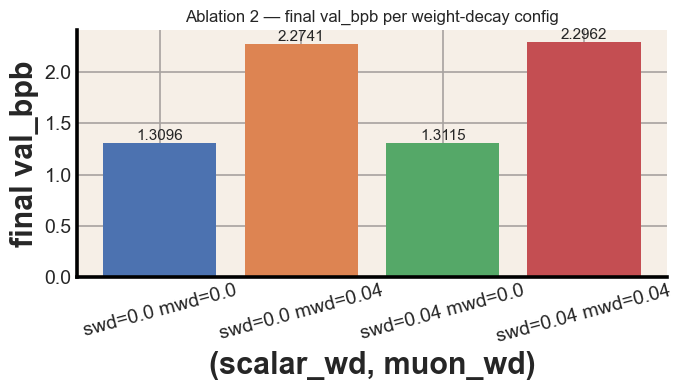

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df["label"], df["final_val_bpb"], color=PALETTE[:len(df)])
ax.set_xlabel("(scalar_wd, muon_wd)")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 2 — final val_bpb per weight-decay config")
ax.tick_params(axis="x", rotation=15)

# annotate bars
for bar, val in zip(bars, df["final_val_bpb"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Learning curves

In [14]:
def fetch_history(run_id_prefix, metric):
    runs = api.runs(
        f"{ENTITY}/{PROJECT}",
        filters={"display_name": {"$regex": f"^{run_id_prefix}"}},
    )
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            swd = run.config.get("scalar_wd", "?")
            mwd = run.config.get("muon_wd", "?")
            label = f"swd={swd} mwd={mwd}"
            histories[label] = hist
    return dict(sorted(histories.items()))

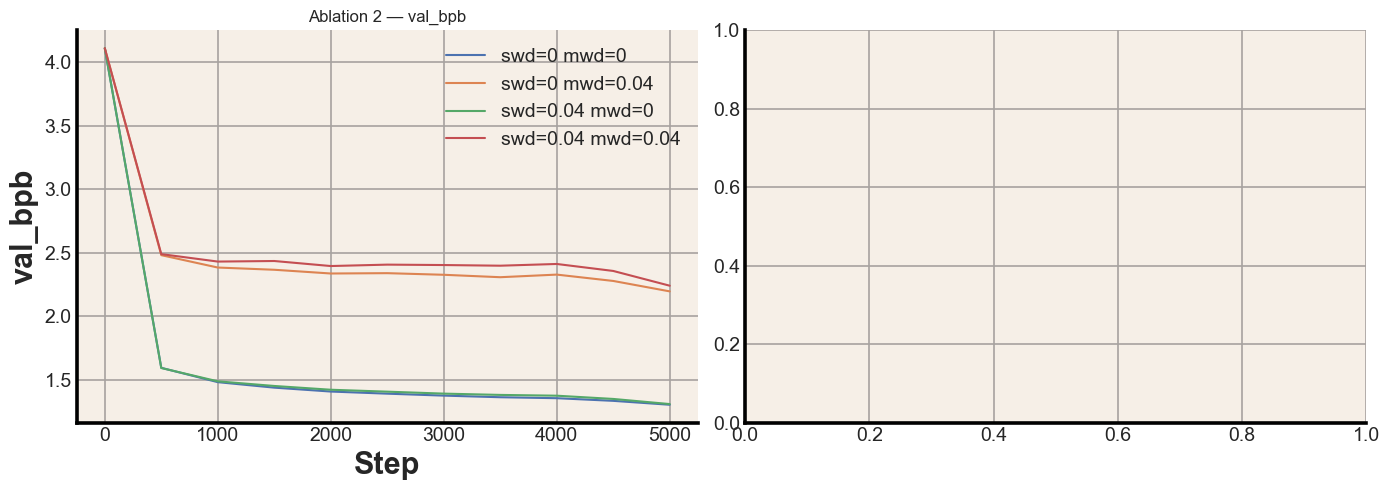

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (metric, ax, title), color in zip(
    [("val_bpb", axes[0], "val_bpb"), ("train_loss", axes[1], "train_loss")],
    [(None, None)],
):
    for (label, hist), color in zip(fetch_history(RUN_ID_PREFIX, metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=label, color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 2 — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

### Weight norms over training

Tracks whether weight decay is actually shrinking the weights as expected.

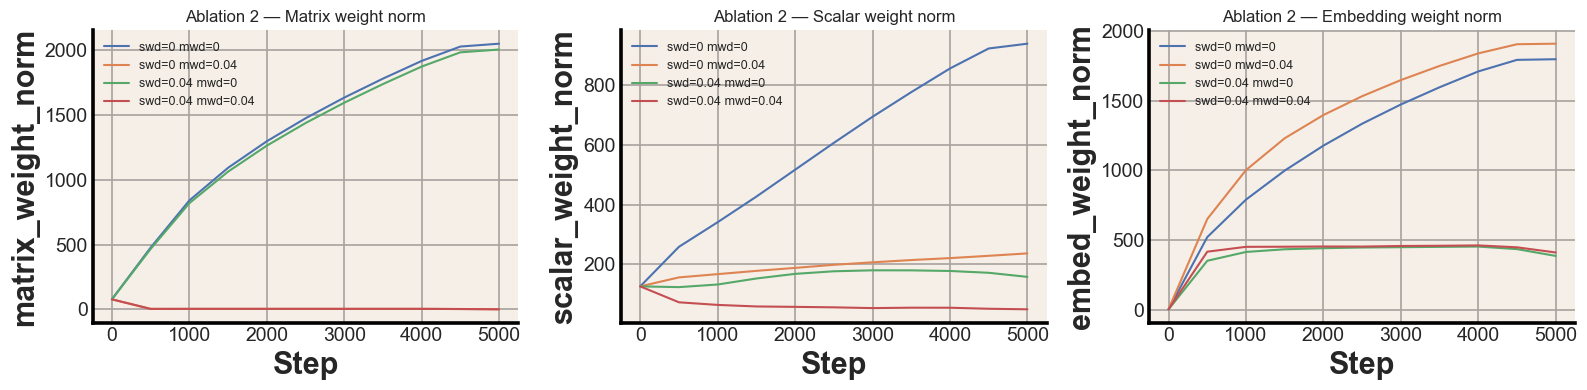

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for (metric, ax, title) in [
    ("matrix_weight_norm", axes[0], "Matrix weight norm"),
    ("scalar_weight_norm", axes[1], "Scalar weight norm"),
    ("embed_weight_norm",  axes[2], "Embedding weight norm"),
]:
    for (label, hist), color in zip(fetch_history(RUN_ID_PREFIX, metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=label, color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 2 — {title}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Gradient norms

`matrix_grad_norm_total` includes the injected L2 term — useful to see if muon_wd is dominating the gradient signal.

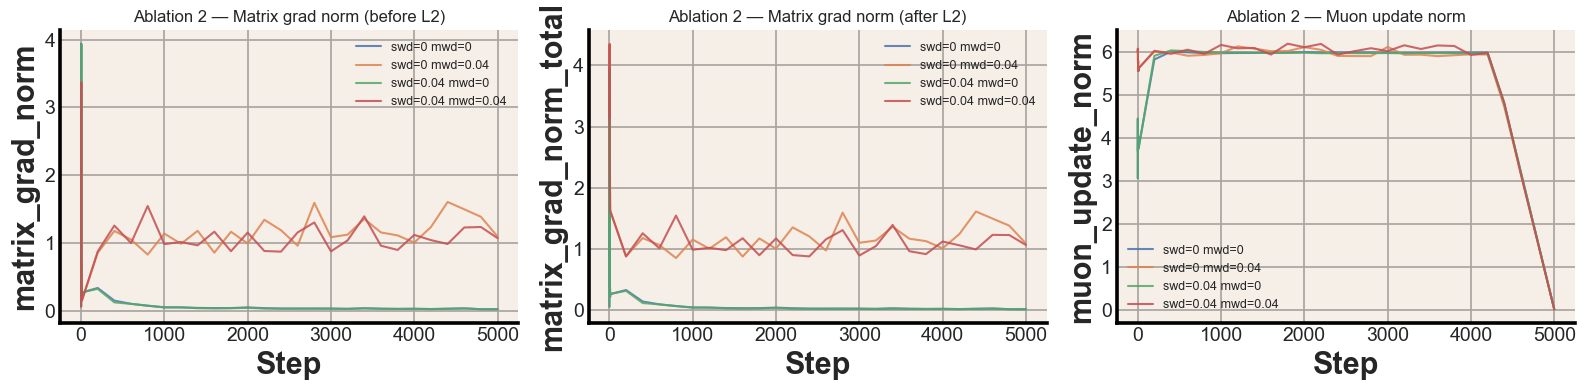

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for (metric, ax, title) in [
    ("matrix_grad_norm",       axes[0], "Matrix grad norm (before L2)"),
    ("matrix_grad_norm_total", axes[1], "Matrix grad norm (after L2)"),
    ("muon_update_norm",       axes[2], "Muon update norm"),
]:
    for (label, hist), color in zip(fetch_history(RUN_ID_PREFIX, metric).items(), PALETTE):
        ax.plot(hist["step"], hist[metric], label=label, color=color, alpha=0.85)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)
    ax.set_title(f"Ablation 2 — {title}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Heatmap — final val_bpb over the 2×2 grid

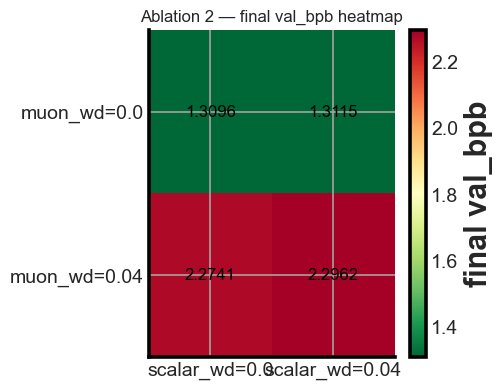

In [18]:
pivot = df.pivot(index="muon_wd", columns="scalar_wd", values="final_val_bpb")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(im, ax=ax, label="final val_bpb")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"scalar_wd={v}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"muon_wd={v}" for v in pivot.index])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.4f}", ha="center", va="center",
                fontsize=12, color="black")

ax.set_title("Ablation 2 — final val_bpb heatmap")
plt.tight_layout()
plt.show()